## SECTION 1 — Imports

In [1]:
import os
import glob
import random

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## SECTION 2 — Constants

In [2]:
# -----------------------------
# Dataset paths
# -----------------------------
AUDIO_DIR = "../ESC-50-master/audio/"
CSV_PATH = "../ESC-50-master/meta/esc50.csv"
REAL_MIC_DIR = "../ESC-50-master/real_mic_data/"

# -----------------------------
# Audio processing parameters
# MUST match the Flutter app exactly. DO NOT CHANGE.
# -----------------------------
SR = 22050
DURATION = 5
N_MELS = 64
MAX_PAD_LEN = 216
N_FFT = 2048
HOP_LENGTH = 512
TOP_DB = 80

# -----------------------------
# Class definitions
# -----------------------------
# The six emergency sounds the app must actively alert the user about.
EMERGENCY_CLASSES = [
    "siren",
    "crying_baby",
    "door_wood_knock",
    "glass_breaking",
    "fireworks",
    "car_horn",
]

# Common everyday / ambient ESC-50 sounds. These exist so the model has
# somewhere legitimate to send non-emergency audio instead of being forced
# to pick an emergency label every single time (this is what was causing
# things like "Fireworks 100%" on silence/background noise).
NEGATIVE_CLASSES = [
    "keyboard_typing",
    "footsteps",
    "clock_tick",
    "mouse_click",
    "rain",
    "wind",
    "breathing",
    "chirping_birds",
    "washing_machine",
    "laughing",
]

# Every class the model will be trained to output.
# Order matters: this order defines the label indices, the CNN's output
# layer, and the labels.txt exported for the Flutter app.
ALL_CLASSES = EMERGENCY_CLASSES + NEGATIVE_CLASSES

NUM_CLASSES = len(ALL_CLASSES)

LABEL_MAP = {category: idx for idx, category in enumerate(ALL_CLASSES)}
INVERSE_LABEL_MAP = {idx: category for category, idx in LABEL_MAP.items()}

# Convenience sets used later for the emergency-vs-non-emergency rollup
EMERGENCY_LABEL_IDS = {LABEL_MAP[c] for c in EMERGENCY_CLASSES}
NEGATIVE_LABEL_IDS = {LABEL_MAP[c] for c in NEGATIVE_CLASSES}

print(f"Emergency classes ({len(EMERGENCY_CLASSES)}): {EMERGENCY_CLASSES}")
print(f"Negative classes  ({len(NEGATIVE_CLASSES)}): {NEGATIVE_CLASSES}")
print(f"Total classes ({NUM_CLASSES}): {ALL_CLASSES}")


Emergency classes (6): ['siren', 'crying_baby', 'door_wood_knock', 'glass_breaking', 'fireworks', 'car_horn']
Negative classes  (10): ['keyboard_typing', 'footsteps', 'clock_tick', 'mouse_click', 'rain', 'wind', 'breathing', 'chirping_birds', 'washing_machine', 'laughing']
Total classes (16): ['siren', 'crying_baby', 'door_wood_knock', 'glass_breaking', 'fireworks', 'car_horn', 'keyboard_typing', 'footsteps', 'clock_tick', 'mouse_click', 'rain', 'wind', 'breathing', 'chirping_birds', 'washing_machine', 'laughing']


## SECTION 3 — Audio Processing

Unchanged from the original pipeline — these parameters must stay pixel-for-pixel identical to what the Flutter app recreates.

In [3]:
def process_audio_to_mel(audio, sr,
                         n_mels=N_MELS,
                         max_pad_len=MAX_PAD_LEN):

    # Ensure exactly 5 seconds
    target_length = SR * DURATION

    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]

    # Compute mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=n_mels,
        power=2.0,
    )

    # Convert to dB
    mel_spec_db = librosa.power_to_db(
        mel_spec,
        ref=np.max,
        top_db=TOP_DB,
    )

    # Pad or trim to MAX_PAD_LEN frames
    if mel_spec_db.shape[1] < max_pad_len:
        pad = max_pad_len - mel_spec_db.shape[1]
        mel_spec_db = np.pad(
            mel_spec_db,
            ((0, 0), (0, pad)),
            mode="constant",
        )
    else:
        mel_spec_db = mel_spec_db[:, :max_pad_len]

    # Standardize each spectrogram
    mean = np.mean(mel_spec_db)
    std = np.std(mel_spec_db)

    mel_spec_db = (mel_spec_db - mean) / (std + 1e-6)

    return mel_spec_db.astype(np.float32)


## SECTION 4 — Data Augmentation

Two layers of augmentation, both applied only to the training split (see Section 8), never to validation or real-mic data:

1. **Waveform-level** — 10 independent techniques (up from 5). `augment_audio` now guarantees at least 2 stack per copy, so augmented samples don't collapse back toward near-duplicates of the original even when generating many copies per clip.
2. **Spectrogram-level (SpecAugment)** — frequency/time masking applied *after* `process_audio_to_mel`, in Section 8. This is effectively free extra diversity since it doesn't require re-decoding or re-transforming audio.

In [4]:
# ------------------------------------------------------------------
# Waveform-level augmentations
# ------------------------------------------------------------------

# Add white noise
def add_noise(data):
    noise_factor = random.uniform(0.001, 0.008)
    noise = np.random.randn(len(data))
    augmented = data + noise_factor * noise
    return np.clip(augmented, -1.0, 1.0)


# Add pink-ish noise (low-frequency-weighted) — a different noise "color"
# than add_noise, approximated cheaply via a cumulative sum of white noise.
def add_pink_noise(data):
    noise_factor = random.uniform(0.001, 0.006)
    white = np.random.randn(len(data))
    pink = np.cumsum(white)
    pink = pink / (np.max(np.abs(pink)) + 1e-9)
    augmented = data + noise_factor * pink
    return np.clip(augmented, -1.0, 1.0)


# Random pitch shift
def pitch_shift(data, sr):
    steps = random.uniform(-2, 2)
    return librosa.effects.pitch_shift(
        y=data,
        sr=sr,
        n_steps=steps,
    )


# Random speed change
def time_stretch(data):
    rate = random.uniform(0.90, 1.10)

    stretched = librosa.effects.time_stretch(
        data,
        rate=rate,
    )

    if len(stretched) > len(data):
        stretched = stretched[:len(data)]
    else:
        stretched = np.pad(
            stretched,
            (0, len(data) - len(stretched)),
        )

    return stretched


# Random volume
def random_gain(data):
    gain = random.uniform(0.8, 1.2)
    augmented = data * gain
    return np.clip(augmented, -1.0, 1.0)


# Random time shift
def time_shift(data):
    shift = random.randint(
        -int(0.15 * len(data)),
        int(0.15 * len(data)),
    )
    return np.roll(data, shift)


# Flip waveform polarity — a free extra sample, cheap to compute
def polarity_invert(data):
    return -data


# Random band-pass filter, approximating different microphone frequency
# responses / room acoustics
def bandpass_filter(data, sr):
    low = random.uniform(50, 300)
    high = random.uniform(4000, min(8000.0, sr / 2 - 100))
    sos = butter(4, [low, high], btype="bandpass", fs=sr, output="sos")
    return sosfiltfilt(sos, data).astype(np.float32)


# Fade in/out envelope, simulating a clip that starts or ends mid-sound
def fade_in_out(data):
    length = len(data)
    fade_len = max(1, int(length * random.uniform(0.05, 0.2)))
    envelope = np.ones(length)
    envelope[:fade_len] = np.linspace(0, 1, fade_len)
    envelope[-fade_len:] = np.linspace(1, 0, fade_len)
    return data * envelope


# Randomly silence a short waveform segment, simulating mic dropout
def random_silence_gap(data):
    length = len(data)
    gap_len = max(1, int(length * random.uniform(0.02, 0.08)))
    start = random.randint(0, length - gap_len)
    augmented = np.copy(data)
    augmented[start:start + gap_len] = 0.0
    return augmented


# All waveform augmentations, paired with whether they need `sr`
_WAVEFORM_AUGMENTATIONS = [
    lambda a, sr: add_noise(a),
    lambda a, sr: add_pink_noise(a),
    lambda a, sr: pitch_shift(a, sr),
    lambda a, sr: time_stretch(a),
    lambda a, sr: random_gain(a),
    lambda a, sr: time_shift(a),
    lambda a, sr: polarity_invert(a),
    lambda a, sr: bandpass_filter(a, sr),
    lambda a, sr: fade_in_out(a),
    lambda a, sr: random_silence_gap(a),
]


# Random augmentation pipeline: each technique is independently rolled,
# with a floor of at least `min_ops` techniques stacked so no augmented
# copy is ever near-identical to the original clip.
def augment_audio(data, sr, apply_prob=0.4, min_ops=2):

    audio = np.copy(data)
    applied = 0

    order = list(_WAVEFORM_AUGMENTATIONS)
    random.shuffle(order)

    for fn in order:
        if random.random() < apply_prob:
            audio = fn(audio, sr)
            applied += 1

    if applied < min_ops:
        for fn in random.sample(order, min_ops - applied):
            audio = fn(audio, sr)

    return audio


# ------------------------------------------------------------------
# Spectrogram-level augmentation (SpecAugment), applied after
# process_audio_to_mel — see Section 8 for where this gets called.
# ------------------------------------------------------------------

def spec_freq_mask(mel_db, num_masks=1, max_width=8):
    mel_db = mel_db.copy()
    n_mels = mel_db.shape[0]
    fill_value = mel_db.min()
    for _ in range(num_masks):
        width = random.randint(1, max_width)
        start = random.randint(0, max(0, n_mels - width))
        mel_db[start:start + width, :] = fill_value
    return mel_db


def spec_time_mask(mel_db, num_masks=1, max_width=16):
    mel_db = mel_db.copy()
    n_frames = mel_db.shape[1]
    fill_value = mel_db.min()
    for _ in range(num_masks):
        width = random.randint(1, max_width)
        start = random.randint(0, max(0, n_frames - width))
        mel_db[:, start:start + width] = fill_value
    return mel_db


def apply_spec_augment(mel_db, prob=0.5):
    if random.random() < prob:
        mel_db = spec_freq_mask(mel_db)
    if random.random() < prob:
        mel_db = spec_time_mask(mel_db)
    return mel_db


## SECTION 5 — Load ESC-50

Loads **only** `ALL_CLASSES` (emergency + negative) from ESC-50. This is the key change from the original notebook, which only ever loaded the 6 emergency classes.

In [5]:
print("Loading ESC-50 clips...")
raw_clips = []

df = pd.read_csv(CSV_PATH)
df_filtered = df[df["category"].isin(ALL_CLASSES)].reset_index(drop=True)

missing_classes = set(ALL_CLASSES) - set(df_filtered["category"].unique())
if missing_classes:
    print(f"WARNING: these classes were not found in {CSV_PATH}: {missing_classes}")

for _, row in df_filtered.iterrows():
    path = os.path.join(AUDIO_DIR, row["filename"])
    try:
        audio, sr = librosa.load(path, sr=SR, res_type="kaiser_fast")
        label = LABEL_MAP[row["category"]]
        raw_clips.append((audio, sr, label))
    except Exception as e:
        print(f"Warning: {path} - {e}")

print(f"Loaded {len(raw_clips)} ESC-50 clips across {len(ALL_CLASSES)} classes")

# Per-class counts, useful to catch missing/short categories early
counts = pd.Series([INVERSE_LABEL_MAP[c[2]] for c in raw_clips]).value_counts()
print("\nPer-class clip counts:")
print(counts.reindex(ALL_CLASSES))


Loading ESC-50 clips...


c:\Users\ACER\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ACER\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ACER\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


Loaded 640 ESC-50 clips across 16 classes

Per-class clip counts:
siren              40
crying_baby        40
door_wood_knock    40
glass_breaking     40
fireworks          40
car_horn           40
keyboard_typing    40
footsteps          40
clock_tick         40
mouse_click        40
rain               40
wind               40
breathing          40
chirping_birds     40
washing_machine    40
laughing           40
Name: count, dtype: int64


## SECTION 6 — Load Real Microphone Dataset

These recordings are **never** used for training or validation — held out purely for final, real-world evaluation (Section 13). Only folders that actually exist under `REAL_MIC_DIR` are loaded, so this works whether you only have recordings for the emergency classes or have also started collecting negative-class recordings.

In [6]:
print("\nLoading real microphone clips (held-out evaluation set only)...")
real_test_clips = []

for category in ALL_CLASSES:
    class_dir = os.path.join(REAL_MIC_DIR, category)
    if not os.path.isdir(class_dir):
        continue  # no real-mic recordings collected for this class yet

    files = glob.glob(os.path.join(class_dir, "*"))
    for path in files:
        try:
            audio, sr = librosa.load(path, sr=SR, res_type="kaiser_fast")
            target_len = SR * DURATION
            if len(audio) < target_len:
                audio = np.pad(audio, (0, target_len - len(audio)))
            else:
                audio = audio[:target_len]
            real_test_clips.append((audio, sr, LABEL_MAP[category]))
        except Exception as e:
            print(f"Warning: {path} - {e}")

print(f"Loaded {len(real_test_clips)} real microphone clips for evaluation")

if real_test_clips:
    real_counts = pd.Series([INVERSE_LABEL_MAP[c[2]] for c in real_test_clips]).value_counts()
    print("\nPer-class real-mic clip counts:")
    print(real_counts)
else:
    print("No real microphone recordings found under REAL_MIC_DIR.")



Loading real microphone clips (held-out evaluation set only)...
Loaded 30 real microphone clips for evaluation

Per-class real-mic clip counts:
siren              5
crying_baby        5
door_wood_knock    5
glass_breaking     5
fireworks          5
car_horn           5
Name: count, dtype: int64


## SECTION 7 — Train / Validation Split

Stratified split on ESC-50 clips only. Real microphone recordings are never part of this split.

In [7]:
labels_only = [c[2] for c in raw_clips]

train_idx, val_idx = train_test_split(
    range(len(raw_clips)),
    test_size=0.2,
    random_state=SEED,
    stratify=labels_only,
)

train_raw = [raw_clips[i] for i in train_idx]
val_raw = [raw_clips[i] for i in val_idx]

print(f"ESC-50 split: Train {len(train_raw)} | Val {len(val_raw)}")


ESC-50 split: Train 512 | Val 128


## SECTION 8 — Build Dataset

Augmentation is applied **only** to the training set. Validation and real-mic data are processed with `process_audio_to_mel` alone — never augmented.

`AUGMENT_TIMES` controls how many augmented copies are generated per original training clip (raised from 6 to 14, so the training set is now ~15x the raw clip count instead of ~7x). Since Section 4 now has 10 waveform techniques plus SpecAugment masking to draw from, the extra copies stay meaningfully different from each other instead of being near-duplicates. This will make training noticeably slower — lower `AUGMENT_TIMES` if that becomes a problem.

In [8]:
# Number of augmented copies generated per original training clip.
# Total training-set multiplier = 1 (original) + AUGMENT_TIMES.
AUGMENT_TIMES = 14


def build_augmented_set(raw_set, augment=False, augment_times=AUGMENT_TIMES, use_spec_augment=True):

    X = []
    y = []

    for audio, sr, label in raw_set:

        # Always include the original, unaugmented clip
        X.append(process_audio_to_mel(audio, sr))
        y.append(label)

        if augment:
            for _ in range(augment_times):
                augmented_audio = augment_audio(audio, sr)
                mel_db = process_audio_to_mel(augmented_audio, sr)
                if use_spec_augment:
                    mel_db = apply_spec_augment(mel_db)
                X.append(mel_db)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    return X, y


print("Building training set (augmented)...")
X_train, y_train = build_augmented_set(
    train_raw,
    augment=True,
    augment_times=AUGMENT_TIMES,
    use_spec_augment=True,
)

print("Building validation set (no augmentation)...")
X_val, y_val = build_augmented_set(
    val_raw,
    augment=False,
)

print("Building real-world evaluation set (no augmentation)...")
X_real_test, y_real_test = build_augmented_set(
    real_test_clips,
    augment=False,
)

X_train = X_train.reshape(-1, X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(-1, X_val.shape[1], X_val.shape[2], 1)
if len(X_real_test) > 0:
    X_real_test = X_real_test.reshape(-1, X_real_test.shape[1], X_real_test.shape[2], 1)

print(f"\nTrain shape: {X_train.shape}")
print(f"Val shape: {X_val.shape}")
print(f"Real-world eval shape: {X_real_test.shape}")


Building training set (augmented)...
Building validation set (no augmentation)...
Building real-world evaluation set (no augmentation)...

Train shape: (7680, 64, 216, 1)
Val shape: (128, 64, 216, 1)
Real-world eval shape: (30, 64, 216, 1)


## SECTION 9 — Verify Preprocessing

Sanity checks before spending time training: correct tensor shape for the Flutter model input `(64, 216, 1)`, no NaN/Inf values, sensible value ranges, class balance across splits, and a visual check of a spectrogram.

X_train: shape=(7680, 64, 216, 1), min=-11.930, max=12.408, mean=-0.111
X_val: shape=(128, 64, 216, 1), min=-6.801, max=10.311, mean=-0.000
X_real_test: shape=(30, 64, 216, 1), min=-4.662, max=4.057, mean=-0.000

Input tensor shape matches Flutter model input (64, 216, 1): OK

Train label distribution:
siren              480
crying_baby        480
door_wood_knock    480
glass_breaking     480
fireworks          480
car_horn           480
keyboard_typing    480
footsteps          480
clock_tick         480
mouse_click        480
rain               480
wind               480
breathing          480
chirping_birds     480
washing_machine    480
laughing           480
Name: count, dtype: int64

Validation label distribution:
siren              8
crying_baby        8
door_wood_knock    8
glass_breaking     8
fireworks          8
car_horn           8
keyboard_typing    8
footsteps          8
clock_tick         8
mouse_click        8
rain               8
wind               8
breathing         

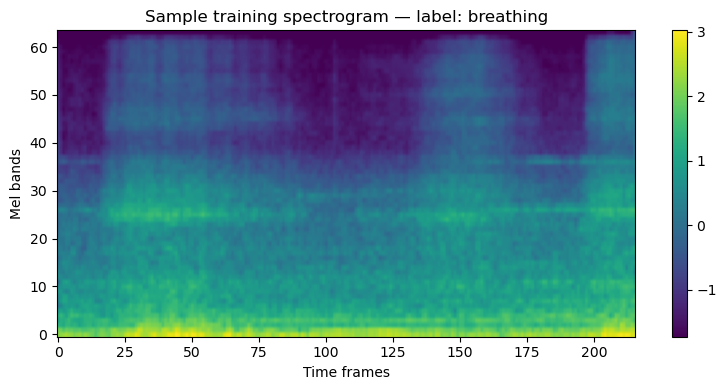

In [9]:
expected_shape = (N_MELS, MAX_PAD_LEN, 1)

assert X_train.shape[1:] == expected_shape, f"Train shape mismatch: {X_train.shape[1:]} != {expected_shape}"
assert X_val.shape[1:] == expected_shape, f"Val shape mismatch: {X_val.shape[1:]} != {expected_shape}"
if len(X_real_test) > 0:
    assert X_real_test.shape[1:] == expected_shape, f"Real-mic shape mismatch: {X_real_test.shape[1:]} != {expected_shape}"

for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_real_test", X_real_test)]:
    if len(arr) == 0:
        continue
    assert not np.isnan(arr).any(), f"{name} contains NaN values"
    assert not np.isinf(arr).any(), f"{name} contains Inf values"
    print(f"{name}: shape={arr.shape}, min={arr.min():.3f}, max={arr.max():.3f}, mean={arr.mean():.3f}")

print("\nInput tensor shape matches Flutter model input (64, 216, 1): OK")

# Class balance across splits
print("\nTrain label distribution:")
print(pd.Series(y_train).map(INVERSE_LABEL_MAP).value_counts().reindex(ALL_CLASSES))

print("\nValidation label distribution:")
print(pd.Series(y_val).map(INVERSE_LABEL_MAP).value_counts().reindex(ALL_CLASSES))

if len(y_real_test) > 0:
    print("\nReal-mic label distribution:")
    print(pd.Series(y_real_test).map(INVERSE_LABEL_MAP).value_counts())

# Visual check of one processed spectrogram
sample_idx = 0
plt.figure(figsize=(8, 4))
plt.imshow(X_train[sample_idx, :, :, 0], aspect="auto", origin="lower")
plt.title(f"Sample training spectrogram — label: {INVERSE_LABEL_MAP[y_train[sample_idx]]}")
plt.xlabel("Time frames")
plt.ylabel("Mel bands")
plt.colorbar()
plt.tight_layout()
plt.show()


## SECTION 10 — Build CNN

Same architecture as before. The only functional change is the output layer size: `len(ALL_CLASSES)` instead of `len(EMERGENCY_CLASSES)`, since the model now has more classes to separate.

In [10]:
model = models.Sequential([

    layers.Input(shape=(N_MELS, MAX_PAD_LEN, 1)),

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.50),

    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 216, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 216, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 216, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 27, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 27, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,144 (438.06 KB)

 Trainable params: 111,696 (436.31 KB)

 Non-trainable params: 448 (1.75 KB)

## SECTION 11 — Train

In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

print("\nTraining...")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=16,
    shuffle=True,
    callbacks=[early_stopping, reduce_lr, checkpoint],
)

# Load the best saved model
model = tf.keras.models.load_model("best_model.keras")



Training...
Epoch 1/80
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1750 - loss: 2.5671
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 50s 99ms/step - accuracy: 0.1751 - loss: 2.5666 - val_accuracy: 0.5000 - val_loss: 1.7024 - learning_rate: 5.0000e-04
Epoch 2/80
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3706 - loss: 1.9073
Epoch 2: val_accuracy improved from 0.50000 to 0.55469, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 48s 100ms/step - accuracy: 0.3707 - loss: 1.9072 - val_accuracy: 0.5547 - val_loss: 1.4655 - learning_rate: 5.0000e-04
Epoch 3/80
480/480 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4685 - loss: 1.6447
Epoch 3: val_accuracy improved from 0.55469 to 0.64062, saving model to best_model.keras
480/480 ━━━━━━━━━━━━━━━━━━━━ 48s 100ms/step - accuracy: 0.4686 - loss: 1.6446 - val_accuracy: 0.6406 - val_loss: 1.2236 - learning_rate: 5.0000e-04
Epoch 4/80
480/480

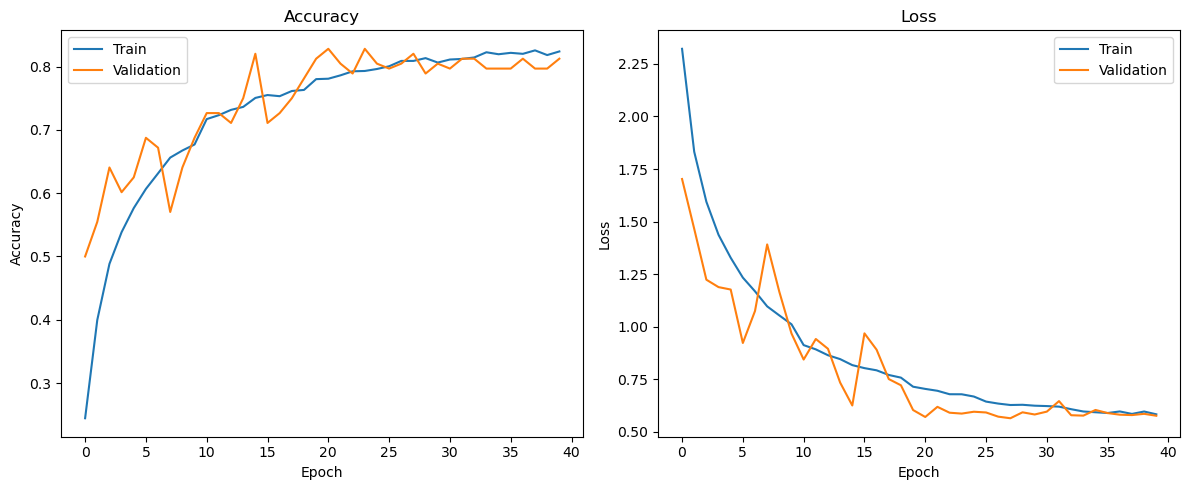

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## SECTION 12 — Evaluation (ESC-50 Validation Set)

Two views are reported:
1. **Full multi-class report** across all `ALL_CLASSES` — this is what the model actually outputs.
2. **Emergency vs. non-emergency rollup** — collapses the 16 classes into a binary "is this an emergency?" decision. This is the metric that most directly answers your original concern (false positives like "Fireworks 100%" on non-emergency audio), since it tells you how often a negative-class sound gets pulled into *any* emergency label, regardless of which one.

In [13]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)

print("=" * 60)
print("VALIDATION SET PERFORMANCE (ESC-50, all classes)")
print("=" * 60)
print(classification_report(y_val, y_val_pred, target_names=ALL_CLASSES, zero_division=0))
print("Confusion Matrix (rows=true, cols=pred), order = ALL_CLASSES:")
print(confusion_matrix(y_val, y_val_pred, labels=list(range(NUM_CLASSES))))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
VALIDATION SET PERFORMANCE (ESC-50, all classes)
                 precision    recall  f1-score   support

          siren       1.00      0.75      0.86         8
    crying_baby       0.80      1.00      0.89         8
door_wood_knock       0.89      1.00      0.94         8
 glass_breaking       0.89      1.00      0.94         8
      fireworks       0.73      1.00      0.84         8
       car_horn       0.89      1.00      0.94         8
keyboard_typing       0.56      0.62      0.59         8
      footsteps       1.00      0.75      0.86         8
     clock_tick       0.80      1.00      0.89         8
    mouse_click       0.33      0.12      0.18         8
           rain       0.89      1.00      0.94         8
           wind       0.70      0.88      0.78         8
      breathing       1.00      0.88      0.93         8
 chirping_birds       0.86      0.75      0.80         8
washing_machine       0.88      0.88      0.88         8


In [14]:
def to_binary_emergency(labels):
    return np.array([1 if l in EMERGENCY_LABEL_IDS else 0 for l in labels])

y_val_binary_true = to_binary_emergency(y_val)
y_val_binary_pred = to_binary_emergency(y_val_pred)

print("\n" + "=" * 60)
print("VALIDATION SET — EMERGENCY vs NON-EMERGENCY ROLLUP")
print("=" * 60)
print(classification_report(
    y_val_binary_true, y_val_binary_pred,
    target_names=["non_emergency", "emergency"],
    zero_division=0,
))
print("Confusion Matrix ([non_emergency, emergency]):")
print(confusion_matrix(y_val_binary_true, y_val_binary_pred))



VALIDATION SET — EMERGENCY vs NON-EMERGENCY ROLLUP
               precision    recall  f1-score   support

non_emergency       0.97      0.90      0.94        80
    emergency       0.85      0.96      0.90        48

     accuracy                           0.92       128
    macro avg       0.91      0.93      0.92       128
 weighted avg       0.93      0.92      0.92       128

Confusion Matrix ([non_emergency, emergency]):
[[72  8]
 [ 2 46]]


## SECTION 13 — Real Microphone Evaluation

Evaluated only on the classes actually present in `REAL_MIC_DIR` (typically just the emergency classes, unless you've also collected real-mic negative-class recordings). This set is never touched during training or validation.

In [15]:
if len(y_real_test) > 0:
    y_real_pred = np.argmax(model.predict(X_real_test), axis=1)

    present_label_ids = sorted(set(y_real_test) | set(y_real_pred))
    present_class_names = [INVERSE_LABEL_MAP[i] for i in present_label_ids]

    print("=" * 60)
    print("REAL-WORLD TEST PERFORMANCE (Phone Microphone Recordings)")
    print("=" * 60)
    print(f"(n={len(y_real_test)})")
    print(classification_report(
        y_real_test, y_real_pred,
        labels=present_label_ids,
        target_names=present_class_names,
        zero_division=0,
    ))
    print("Confusion Matrix:")
    print(confusion_matrix(y_real_test, y_real_pred, labels=present_label_ids))

    # Binary rollup on real-mic data too, since this is the number that
    # matters most for the deployed app's false-positive rate.
    y_real_binary_true = to_binary_emergency(y_real_test)
    y_real_binary_pred = to_binary_emergency(y_real_pred)

    print("\n" + "=" * 60)
    print("REAL-WORLD TEST — EMERGENCY vs NON-EMERGENCY ROLLUP")
    print("=" * 60)
    print(classification_report(
        y_real_binary_true, y_real_binary_pred,
        target_names=["non_emergency", "emergency"],
        zero_division=0,
    ))
    print("Confusion Matrix ([non_emergency, emergency]):")
    print(confusion_matrix(y_real_binary_true, y_real_binary_pred))
else:
    print("No real-world microphone clips loaded — skipping real-mic evaluation.")
    print("(REAL_MIC_DIR must never be used for training/validation, only here.)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
REAL-WORLD TEST PERFORMANCE (Phone Microphone Recordings)
(n=30)
                 precision    recall  f1-score   support

          siren       1.00      0.60      0.75         5
    crying_baby       1.00      1.00      1.00         5
door_wood_knock       1.00      0.20      0.33         5
 glass_breaking       1.00      0.20      0.33         5
      fireworks       1.00      0.20      0.33         5
       car_horn       1.00      0.80      0.89         5
keyboard_typing       0.00      0.00      0.00         0
     clock_tick       0.00      0.00      0.00         0
           rain       0.00      0.00      0.00         0
      breathing       0.00      0.00      0.00         0
 chirping_birds       0.00      0.00      0.00         0
       laughing       0.00      0.00      0.00         0

       accuracy                           0.50        30
      macro avg       0.50      0.25      0.30        30
   weighted avg       1.00      0.50   

## SECTION 14 — Export TensorFlow Lite

`labels.txt` is written in `ALL_CLASSES` order, which matches the model's output layer exactly. **This is a breaking change for the Flutter app**: the output size grows from 6 to 16 classes, so the app's label list and any index-based logic need to be updated to match `labels.txt` before this model is deployed.

In [16]:
print("Exporting to TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("_audio_classifier.tflite", "wb") as f:
    f.write(tflite_model)

with open("labels.txt", "w") as f:
    for category in ALL_CLASSES:
        f.write(f"{category}\n")

print("Saved: _audio_classifier.tflite")
print("Saved: labels.txt")
print(f"\nModel outputs {NUM_CLASSES} classes in this order:")
for idx, category in enumerate(ALL_CLASSES):
    tag = "EMERGENCY" if idx in EMERGENCY_LABEL_IDS else "negative"
    print(f"  {idx}: {category} ({tag})")


Exporting to TFLite...
INFO:tensorflow:Assets written to: C:\Users\ACER\AppData\Local\Temp\tmpkyhlg2b7\assets


INFO:tensorflow:Assets written to: C:\Users\ACER\AppData\Local\Temp\tmpkyhlg2b7\assets


Saved artifact at 'C:\Users\ACER\AppData\Local\Temp\tmpkyhlg2b7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 216, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  1638024900304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638024896464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638024896272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638024895696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638024900112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638024894928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638024896080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638024897808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638024899152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638617282704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1638024